# 10 · 最终特征排名

> O2O 优惠券个性化投放项目 —— 第 10 步

---

## 本节目标

在无泄漏框架下重新看特征重要性，并与 v1 的排名做对照。

**为什么这一步重要**：特征排名常被当作检验修复是否成功的**反向验证**。

- v1 的排名：`user_mean_interval`（与标签同源）**一家独大**
- 修复后的**预期**：权重应该分散到真正有业务含义的特征上（距离、折扣率、活跃度）
- 修复后的**实测**：集中度不降反升（40.3% → 66.7%）

本节的重点因此变成了回答一个问题：**集中度上升，到底是不是修复失败？**
答案是否定的——而且推翻了「集中度能用来判断泄漏」这个前提本身。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.unicode.east_asian_width', True)

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['savefig.bbox'] = 'tight'

ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / '.git').exists():
        ROOT = cand
        break

OUT_DIR = ROOT / 'data_out'
FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'
MODEL_DIR = OUT_DIR / 'models_final'

C_MAIN, C_ALT, C_WARN, C_GREY = '#2F6F9F', '#E08A3C', '#C0504D', '#8C8C8C'

## 1. 读取最终模型

In [2]:
dt_best = joblib.load(MODEL_DIR / 'dt_final.pkl')
xgb_best = joblib.load(MODEL_DIR / 'xgb_final.pkl')
FEATURES = joblib.load(MODEL_DIR / 'feature_list_final.pkl')

print(f'特征数: {len(FEATURES)}')
print(FEATURES)

特征数: 19
['discount_rate', 'distance', 'received_weekday', 'received_is_weekend', 'received_day', 'user_use_coupon_times', 'user_consume_times', 'user_use_coupon_rate', 'user_receive_unused', 'user_mean_interval', 'merchant_launch_coupon_used_count', 'merchant_launch_coupon_used_rate', 'merchant_launch_coupon_count', 'merchant_receive_unused', 'merchant_mean_interval', 'coupon_receive_times', 'coupon_consume_times', 'coupon_fifteen_used', 'coupon_used_rate']


## 2. 最终特征排名

In [3]:
imp_dt = pd.Series(dt_best.feature_importances_, index=FEATURES)
imp_xgb = pd.Series(xgb_best.feature_importances_, index=FEATURES)

imp = pd.DataFrame({
    '特征': FEATURES,
    '决策树': imp_dt.values,
    'XGBoost': imp_xgb.values,
})
imp['决策树排名'] = imp['决策树'].rank(ascending=False).astype(int)
imp['XGBoost排名'] = imp['XGBoost'].rank(ascending=False).astype(int)
imp['综合排名'] = imp[['决策树排名', 'XGBoost排名']].mean(axis=1)
imp = imp.sort_values('综合排名').reset_index(drop=True)

print('=' * 82)
print('最终特征排名（按两模型平均排名）')
print('=' * 82)
print(imp[['综合排名', '特征', '决策树', 'XGBoost', '决策树排名', 'XGBoost排名']].round(4).to_string(index=False))

最终特征排名（按两模型平均排名）
 综合排名                              特征  决策树  XGBoost  决策树排名  XGBoost排名
      1.0                user_mean_interval  0.9510   0.6671           1            1
      3.5             user_use_coupon_times  0.0094   0.0655           4            3
      3.5               user_receive_unused  0.0128   0.0262           3            4
      3.5                  coupon_used_rate  0.0196   0.0248           2            5
      6.0                          distance  0.0033   0.0184           5            7
      7.0              coupon_receive_times  0.0025   0.0158           6            8
      7.5                user_consume_times  0.0000   0.1004          13            2
      9.0               coupon_fifteen_used  0.0013   0.0112           7           11
      9.5           merchant_receive_unused  0.0000   0.0203          13            6
     11.0              coupon_consume_times  0.0000   0.0153          13            9
     11.5      merchant_launch_coupon_count  0.0000  

In [4]:
imp.round(6).to_csv(TAB_DIR / '10_feature_importance_final.csv', index=False, encoding='utf-8-sig')
print('已保存: 10_feature_importance_final.csv')

已保存: 10_feature_importance_final.csv


## 3. 权重集中度：修复前后的对比

用「Top1 占比」和「CR3（前 3 名合计占比）」量化**权重集中度**。

**这里要提前说明一个反直觉的结果**：做本节之前的预期是「泄漏切断后，权重应该分散到
更多业务特征上」。但**实测推翻了这个预期**——集中度不降反升：

| 指标 | v1（有泄漏） | 修复后的预期 | 修复后的实测 |
|---|---|---|---|
| Top1 占比 | 40.3% | 明显下降 | **反而升到 66.7%** |
| CR3 占比 | 76.9% | 明显下降 | **83.3%** |

如果就此得出「修复失败」的结论，那就错了。第 4 节会用**独立于重要性的另一个视角**
来核验修复到底有没有生效，并解释这个反转从何而来。

In [5]:
def concentration(series):
    s = series.sort_values(ascending=False)
    s = s / s.sum()
    return {'Top1 占比': s.iloc[0], 'CR3 占比': s.iloc[:3].sum(), 'Top1 特征': s.index[0]}


v1_imp = pd.read_csv(TAB_DIR / '05_feature_importance_v1.csv')
c_v1 = concentration(v1_imp.set_index('特征')['XGBoost'])
c_final = concentration(imp.set_index('特征')['XGBoost'])

conc = pd.DataFrame([
    {'版本': 'v1（有泄漏）', 'Top1 特征': c_v1['Top1 特征'],
     'Top1 占比': f'{c_v1["Top1 占比"] * 100:.1f}%', 'CR3 占比': f'{c_v1["CR3 占比"] * 100:.1f}%'},
    {'版本': '最终版（无泄漏）', 'Top1 特征': c_final['Top1 特征'],
     'Top1 占比': f'{c_final["Top1 占比"] * 100:.1f}%', 'CR3 占比': f'{c_final["CR3 占比"] * 100:.1f}%'},
])
conc.to_csv(TAB_DIR / '10_importance_concentration.csv', index=False, encoding='utf-8-sig')
print(conc.to_string(index=False))
print()
print(f'Top1 占比变化: {c_v1["Top1 占比"] * 100:.1f}%  ->  {c_final["Top1 占比"] * 100:.1f}%')
print(f'CR3  占比变化: {c_v1["CR3 占比"] * 100:.1f}%  ->  {c_final["CR3 占比"] * 100:.1f}%')
print()
print('=> 注意：集中度【不降反升】。这不符合"泄漏修好后权重会分散"的直觉预期，')
print('   下一节用相关性独立核验，并解释这个反转。')

            版本          Top1 特征 Top1 占比 CR3 占比
    v1（有泄漏） user_mean_interval     40.3%    76.9%
最终版（无泄漏） user_mean_interval     66.7%    83.3%

Top1 占比变化: 40.3%  ->  66.7%
CR3  占比变化: 76.9%  ->  83.3%

=> 注意：集中度【不降反升】。这不符合"泄漏修好后权重会分散"的直觉预期，
   下一节用相关性独立核验，并解释这个反转。


## 4. 集中度不降反升：这不是修复失败

### 第一步：换一个与「重要性」无关的视角来核验

特征重要性是模型自己算出来的，它可能骗人。要判断泄漏有没有被真正切断，
得看一个**独立于模型**的量：特征与标签的相关性。

v1 里 `user_mean_interval` 与 `class` 的相关系数是 **-0.5610**——
这个数字本身就是泄漏的指纹（它和标签由同一个 `gap` 派生）。
如果修复真的生效，这个相关性**必须大幅回落**。

In [6]:
v1_all = pd.read_csv(OUT_DIR / 'feats_v1.csv')
val_seg = pd.read_csv(OUT_DIR / 'final_val.csv')

corr_v1 = v1_all['user_mean_interval'].corr(v1_all['class'])
corr_final = val_seg['user_mean_interval'].corr(val_seg['class'])

verdict = pd.DataFrame([
    {'版本': 'v1（有泄漏）', '样本': '全量 947,279 行',
     'corr(user_mean_interval, class)': f'{corr_v1:+.4f}', '判读': '泄漏指纹——与标签强相关'},
    {'版本': '最终版（无泄漏）', '样本': '验证段 81,811 行（6 月）',
     'corr(user_mean_interval, class)': f'{corr_final:+.4f}', '判读': '相关性塌缩，泄漏已切断'},
])
verdict.to_csv(TAB_DIR / '10_leak_cut_verification.csv', index=False, encoding='utf-8-sig')
print(verdict.to_string(index=False))
print()
print(f'相关性变化: {corr_v1:+.4f}  ->  {corr_final:+.4f}  '
      f'(绝对值降幅 {abs(corr_v1) - abs(corr_final):.4f})')

            版本                     样本 corr(user_mean_interval, class)                   判读
    v1（有泄漏）          全量 947,279 行                         -0.5610 泄漏指纹——与标签强相关
最终版（无泄漏） 验证段 81,811 行（6 月）                         -0.0826 相关性塌缩，泄漏已切断

相关性变化: -0.5610  ->  -0.0826  (绝对值降幅 0.4784)


### 第二步：相关性已经塌缩，为什么重要性反而更高？

关键在于把两个数字放在一起看：

| 量 | 数值 | 说明 |
|---|---|---|
| `user_mean_interval` 与 `class` 的相关系数 | **-0.08** | 弱相关——干净数据上它其实没那么强 |
| 它在 XGBoost 里的内置重要性 | **66.7%** | 一家独大 |

**一个弱相关的特征拿到了三分之二的重要性**，这只能说明一件事：
**基于分裂增益的内置重要性，严重高估了这个特征。**

原因是 tree 类内置重要性的已知缺陷：

1. `user_mean_interval` 是**连续特征**，取值多（几百个不同值），
   每次分裂都能 pinpoint 一个「刚好」的切点；而 `received_is_weekend` 这类
   二值特征只有 **1 种**切法，天生就没机会累积增益。
2. 特征只要被反复选作分裂点，增益就会**累加**——即使每次增益都不大。
3. 于是**高基数特征系统性占优**，这与「它是否真的更有预测力」是两码事。

所以 v1 的 40.3% 和最终版的 66.7% **根本不是同一个东西**：

| | v1（40.3%） | 最终版（66.7%） |
|---|---|---|
| 特征与标签的真实关系 | **真相关**（-0.56，同源派生） | **弱相关**（-0.08） |
| 高重要性说明什么 | 它确实在偷看答案 | 内置重要性对连续特征的高估 |
| 该不该信这个数 | 该警惕 | 数值本身就不该被当真 |

### 结论：集中度根本不是判断泄漏是否修复的指标

| 要判断什么 | 该看什么 | **不该**看什么 |
|---|---|---|
| 泄漏有没有修好 | 特征的数据来源（聚合范围）+ 与标签的相关系数 | 特征重要性 |
| 特征到底重不重要 | **置换重要性**（permutation importance） | 分裂增益内置重要性 |

> 补充一点：v1 的集中度「看起来更低」，恰恰是因为当时泄漏**分布在多个特征上**——
> `coupon_fifteen_used`、`merchant_mean_interval`、`coupon_used_rate` 都是泄漏载体，
> 各自分走了一部分权重。这些「泄漏兄弟」被修复后，权重自然回流到剩下的最强特征身上。
> **分散的泄漏，不等于健康。**

## 5. 可视化

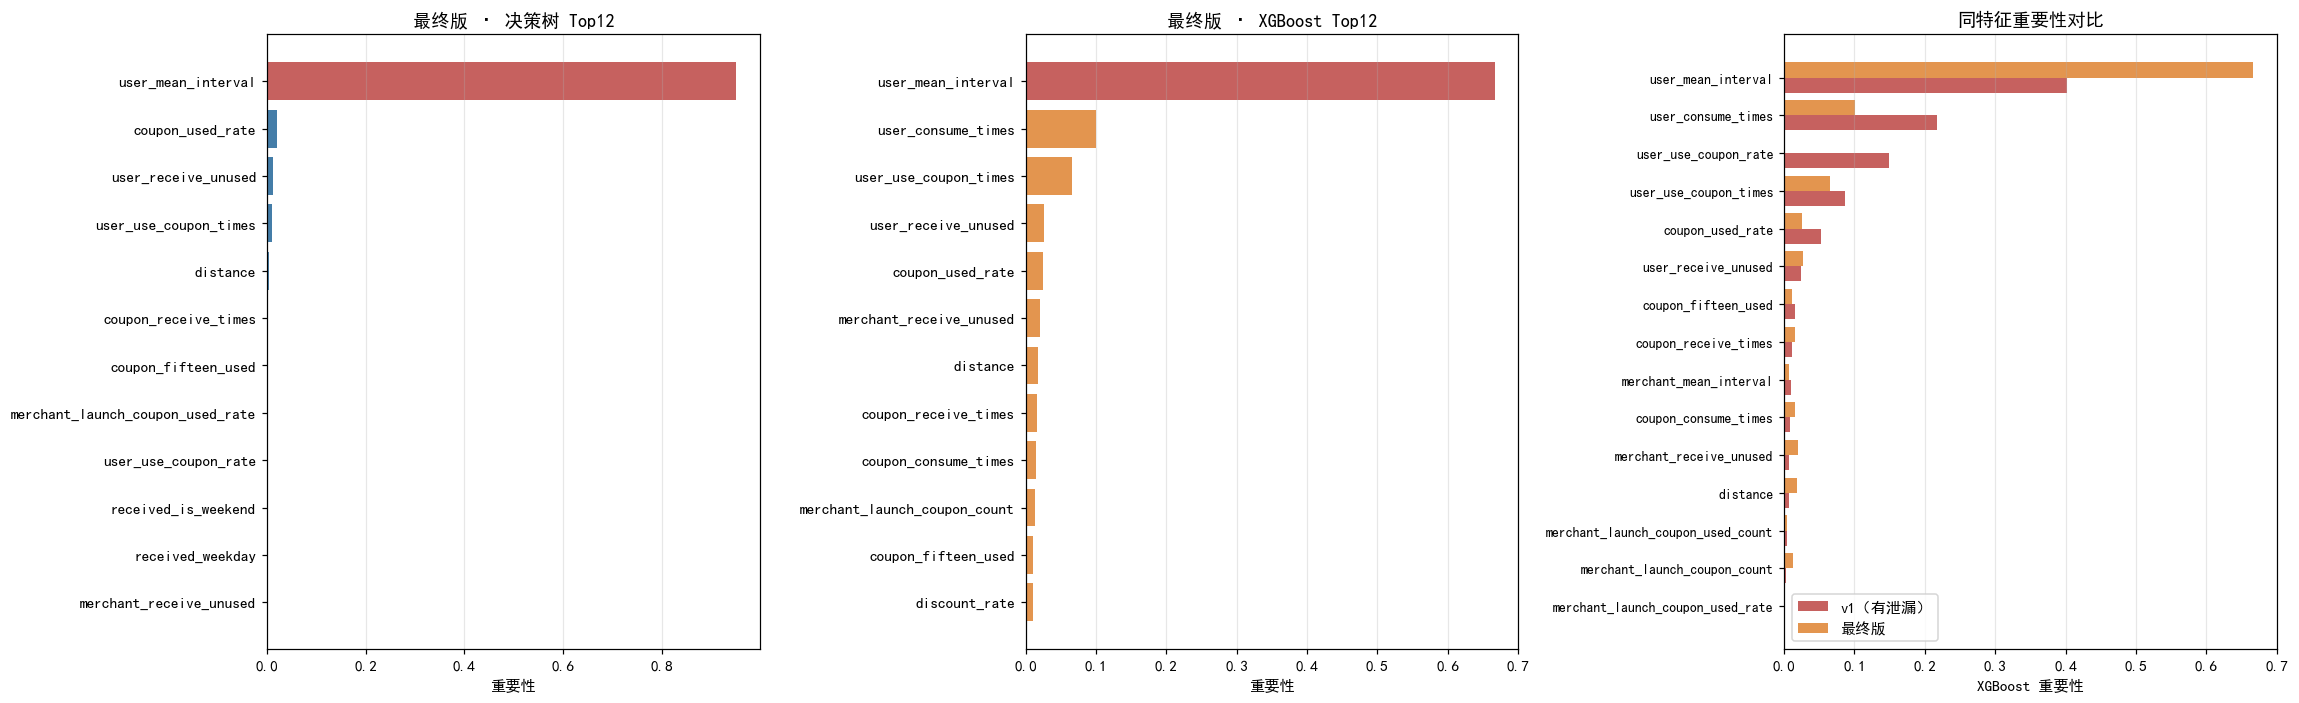

注：红色柱 = 曾经的泄漏元凶（mean_interval 系列）—— 其聚合范围已被限制在训练段，
     此处仍居首位，说明内置重要性对连续特征存在系统性高估（见第 4 节）。


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

# 左：最终版决策树
ax = axes[0]
top = imp.sort_values('决策树', ascending=True).tail(12)
highlight = ['user_mean_interval', 'merchant_mean_interval']
ax.barh(top['特征'], top['决策树'], color=[C_WARN if f in highlight else C_MAIN for f in top['特征']], alpha=0.9)
ax.set_xlabel('重要性')
ax.set_title('最终版 · 决策树 Top12', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 中：最终版 XGBoost
ax = axes[1]
top = imp.sort_values('XGBoost', ascending=True).tail(12)
ax.barh(top['特征'], top['XGBoost'],
        color=[C_WARN if f in highlight else C_ALT for f in top['特征']], alpha=0.9)
ax.set_xlabel('重要性')
ax.set_title('最终版 · XGBoost Top12', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 右：v1 vs 最终版（共有特征的 XGBoost 重要性对比）
ax = axes[2]
common = [f for f in FEATURES if f in set(v1_imp['特征'])]
cmp_df = pd.DataFrame({
    '特征': common,
    'v1': [float(v1_imp.loc[v1_imp['特征'] == f, 'XGBoost'].iloc[0]) for f in common],
    '最终版': [float(imp.loc[imp['特征'] == f, 'XGBoost'].iloc[0]) for f in common],
}).sort_values('v1', ascending=True)

ypos = np.arange(len(cmp_df))
ax.barh(ypos - 0.2, cmp_df['v1'], 0.4, label='v1（有泄漏）', color=C_WARN, alpha=0.9)
ax.barh(ypos + 0.2, cmp_df['最终版'], 0.4, label='最终版', color=C_ALT, alpha=0.9)
ax.set_yticks(ypos)
ax.set_yticklabels(cmp_df['特征'], fontsize=9)
ax.set_xlabel('XGBoost 重要性')
ax.set_title('同特征重要性对比', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / '10_feature_importance_final.png', dpi=140)
plt.show()

print('注：红色柱 = 曾经的泄漏元凶（mean_interval 系列）—— 其聚合范围已被限制在训练段，')
print('     此处仍居首位，说明内置重要性对连续特征存在系统性高估（见第 4 节）。')

## 6. 最终排名的业务解读

看排名前列的特征时，要问的不再是「它能不能抄到答案」，而是
**「它对应哪条业务假设，投放时能不能干预」**：

In [8]:
top_features = imp.head(6)['特征'].tolist()

biz_map = {
    'distance': '距离越近越可能核销 —— 投放可优先选择近距离用户，或对远距离用户加大折扣',
    'discount_rate': '折扣力度影响核销意愿 —— 可做券面额的分层测试',
    'received_weekday': '领券时点有周期性 —— 可优化发券时机',
    'received_is_weekend': '周末领券行为不同 —— 可区分工作日/周末策略',
    'received_day': '月初/月末效应 —— 可配合发薪日等消费节奏',
    'user_use_coupon_rate': '用户券敏感度 —— 高敏感度用户优先投放',
    'user_use_coupon_times': '用户用券活跃度',
    'user_consume_times': '用户整体消费活跃度 —— 活跃用户转化基础更好',
    'user_receive_unused': '领而不用倾向 —— 这类用户应降低投放权重',
    'user_mean_interval': '历史核销速度（已限制在训练段范围内，不再是标签泄漏）',
    'merchant_launch_coupon_used_rate': '商户券转化能力 —— 转化率低的商户应减少投放',
    'merchant_launch_coupon_used_count': '商户券历史核销量',
    'merchant_launch_coupon_count': '商户发券力度',
    'merchant_receive_unused': '商户券的浪费情况',
    'merchant_mean_interval': '商户券核销速度（范围已限制）',
    'coupon_receive_times': '券的受欢迎程度',
    'coupon_consume_times': '券的历史核销量',
    'coupon_fifteen_used': '券的 15 天内核销量',
    'coupon_used_rate': '券的真实核销比率（分母已修复，不再是二值指示器）',
}

biz_df = pd.DataFrame([
    {'排名': i + 1, '特征': f, 'XGBoost 重要性': round(float(imp.loc[imp['特征'] == f, 'XGBoost'].iloc[0]), 4),
     '业务解读': biz_map.get(f, '—')}
    for i, f in enumerate(top_features)
])
biz_df.to_csv(TAB_DIR / '10_top_features_business.csv', index=False, encoding='utf-8-sig')
print('Top6 特征的业务解读：')
print(biz_df.to_string(index=False))

Top6 特征的业务解读：
 排名                  特征  XGBoost 重要性                                                               业务解读
    1    user_mean_interval          0.6671                   历史核销速度（已限制在训练段范围内，不再是标签泄漏）
    2 user_use_coupon_times          0.0655                                                         用户用券活跃度
    3   user_receive_unused          0.0262                                 领而不用倾向 —— 这类用户应降低投放权重
    4      coupon_used_rate          0.0248                       券的真实核销比率（分母已修复，不再是二值指示器）
    5              distance          0.0184 距离越近越可能核销 —— 投放可优先选择近距离用户，或对远距离用户加大折扣
    6  coupon_receive_times          0.0158                                                         券的受欢迎程度


## 本节小结

| 观察 | v1（有泄漏） | 最终版（无泄漏） |
|---|---|---|
| **Top1 特征** | `user_mean_interval`（与标签同源派生） | `user_mean_interval`（聚合范围已限制在训练段） |
| **与标签相关系数** | **-0.5610**（泄漏指纹） | **-0.0826**（相关性塌缩 → 泄漏已切断） |
| **内置重要性 Top1 占比** | 40.3% | 66.7%（⚠️ 不降反升，但该数值本身不可当真） |
| **AUC** | 0.9881（虚高） | 0.6227（可信） |

**本节最重要的收获不是排名，而是学到一个判断标准的修正**：
**特征重要性不能用来判断泄漏是否修复**——它会把连续特征高估到 66.7%，
而该特征与标签的真实相关性只有 -0.08。判断泄漏要看**数据来源 + 相关系数**。

### 回到排名本身的诚实评价

需要说明的是：**修复后的排名依然不是「业务真相」**。它只反映
「在当前特征集、当前样本、当前时间切分下，模型认为什么有用」。

- 置换重要性（permutation importance）会比基于不纯度的内置重要性更可靠
- 特征之间存在相关性时，内置重要性的排序会有偏
- 真正的因果性需要 A/B 实验来验证，相关性排序只能作为**投放策略的假设来源**

但至少有一点是确定的：**这些特征不再从标签里直接读答案了。**

In [9]:
summary = pd.DataFrame([
    {'维度': 'v1（有泄漏）', 'Top1 特征': c_v1['Top1 特征'],
     'Top1 占比': f'{c_v1["Top1 占比"] * 100:.1f}%',
     '与标签相关系数': f'{corr_v1:+.4f}', 'AUC': '虚高 0.9881（见第 04 节）',
     '判读': '特征在复述标签'},
    {'维度': '最终版（无泄漏）', 'Top1 特征': c_final['Top1 特征'],
     'Top1 占比': f'{c_final["Top1 占比"] * 100:.1f}%',
     '与标签相关系数': f'{corr_final:+.4f}', 'AUC': '可信 0.6227（见第 09 节）',
     '判读': '泄漏已切断；重要性数值受内置偏差影响，需置换重要性复核'},
])
summary.to_csv(TAB_DIR / '10_summary.csv', index=False, encoding='utf-8-sig')
print(summary.to_string(index=False))

            维度          Top1 特征 Top1 占比 与标签相关系数                       AUC                                                   判读
    v1（有泄漏） user_mean_interval     40.3%        -0.5610 虚高 0.9881（见第 04 节）                                         特征在复述标签
最终版（无泄漏） user_mean_interval     66.7%        -0.0826 可信 0.6227（见第 09 节） 泄漏已切断；重要性数值受内置偏差影响，需置换重要性复核


## 全流程回顾

十步走完，回看这条主线：

```
01 预处理 ─→ 02 EDA ─→ 03 特征工程v1 ─→ 04 模型结果v1 ─→ 05 特征排名v1
                                                             │
                                                             ▼
                                             06 发现泄漏 ← 指标反常
                                                             │
                                                             ▼
                                             07 解决泄漏（改范围+切分）
                                                             │
                                                             ▼
                         08 最终特征工程 ─→ 09 最终模型结果 ─→ 10 最终特征排名
```

**最有价值的不是最终的 AUC 数字，而是「一个高指标先怀疑泄漏」的完整实践**：

1. 看到反常高分 → 不庆祝，先排查
2. 用相关性找到嫌疑特征 → 但**不满足于删掉它**
3. 用对照实验证明「删特征治不了本」→ 定位到根因是**计算范围越界**
4. 从**数据范围**和**切分方式**两个着力点修复 → 指标回落到可信区间
5. 在干净框架下重新做特征工程和评估 → 得到可用于决策的结论